In [1]:
from InSitu14CO import Propagator
import numpy as np
import matplotlib.pyplot as plt
import crflux.models as pm
import matplotlib.ticker as ticker
import matplotlib as mpl
import Functions_14CO as F

from tqdm import tqdm

import pandas as pd

from scipy import stats

In [2]:
# setup pyplot formatting

axes_style = { 'grid'      : 'True',
               'labelsize' : '14',
               'labelpad'  : '8.0'
             }
grid_style = { 'alpha'     : '0.75',
               'linestyle' : ':' }
font_style = { 'size'      : '10' }

mpl.rc('font', **font_style)
mpl.rc('axes', **axes_style)
mpl.rc('grid', **grid_style)

In [3]:
def T(A):
    return np.swapaxes(A, -2, -1)

## Load Production Rates

In [5]:
Prop = Propagator(logE_mu_max=7.5)

In [6]:
# load production rates
df_Pfast = pd.read_csv('Production Rates/P_fast_3120m.csv')
df_Pneg = pd.read_csv('Production Rates/P_neg_3120m.csv')
P_14C = np.swapaxes([df_Pfast.T, df_Pneg.T], 0, 1)
model_names = list(df_Pfast.columns)

In [7]:
# calculate 14CO concentrations (without f-factors)
Prop.Phi['prod']=P_14C
C_flow = F.flow_14C(Prop)

100%|█████████████████████████████████████████████████████████████████████████████| 7283/7283 [00:58<00:00, 125.18it/s]


In [8]:
# load f-factors
df = pd.read_csv('factors_2sigma_hull.csv', header=None)
f_factors = np.array([df[1],df[0]]).T

In [9]:
# calculate 14CO concentrations (with f-factors)
CO = (f_factors @ C_flow).reshape((-1,np.shape(C_flow)[-1]))

In [10]:
# store predicted 14CO concentrations in Propogator
Prop.Phi['CO'] = CO

We now use all our models to calculate the average predicted $^{14}$CO and the covariance between each sample depth.

The covariance between two random values $a$ and $b$ is:
$$\text{Cov}(a,b) = \langle ab\rangle - \langle a\rangle \langle b\rangle,$$
where $\langle \rangle$ denotes the expected or mean value.

If $a$ and $b$ are independent, then the covariance is 0.

If $a=b$, then the covariance is the variance of $a$:
$$\text{Var}(a) = \langle a^2 \rangle - \langle a \rangle^2,$$
which is the square of the standard deviation.

The covariance matrix $\Sigma$ of a vector $\vec{v}$ is an array of the covariances between all pairs of $\vec{v}$'s components:

$$\Sigma_{ij} = \text{Cov}(v_i,v_j)$$

Because $\text{Cov}(a,b) = \text{Cov}(b,a)$, all covariance matrices are symmetric.

In [11]:
# calculate mean & systematic uncertainty for 14CO predictions at sample depths
Prop.calc_gauss_pred()

print(Prop.c_pred) # mean
print(Prop.cov_pred) # covariance matrix

[ 4.68362916  9.62076806 12.78299618 14.78229854 16.00986132 16.67425941
 16.95764713 16.95392116 16.73998124 16.3998081 ]
[[ 2.231447    4.86748418  6.79216925  8.16980006  9.13958687  9.78129482
  10.18694399 10.39839564 10.46143092 10.41308843]
 [ 4.86748418 10.62609792 14.83778835 17.8570003  19.98567221 21.39693153
  22.29154116 22.76060906 22.90426517 22.80312933]
 [ 6.79216925 14.83778835 20.73045999 24.96020855 27.94631131 29.92929875
  31.18933549 31.8532904  32.06119085 31.92530993]
 [ 8.16980006 17.8570003  24.96020855 30.06436713 33.67174697 36.07059464
  37.59789514 38.40596978 38.6635406  38.50541311]
 [ 9.13958687 19.98567221 27.94631131 33.67174697 37.72195166 40.41837138
  42.13797424 43.05088892 43.34613384 43.17428098]
 [ 9.78129482 21.39693153 29.92929875 36.07059464 40.41837138 43.31571656
  45.16603913 46.15115755 46.47359956 46.29428871]
 [10.18694399 22.29154116 31.18933549 37.59789514 42.13797424 45.16603913
  47.10219786 48.13557171 48.47730085 48.29477677]
 [

To generate each random sample, we use the average & covariance of our prediction to produce a random "True" $^{14}$CO profile.

We then introduce a 2% experimental error.

In [12]:
# generate random samples
c, c_err = Prop.get_samples(int(5e4), rel_err=0.02)

Now we calculate the log likelihood test statistic, like so:

$$\log L = -\frac{1}{2}(\vec{c}-\hat{c})^T \Sigma^{-1}(\vec{c}-\hat{c}) - \frac{1}{2}\log(|2\pi\Sigma|)$$

Where $\vec{c}$ is the measurement (`c`), $\hat{c}$ is the prediction (`c_pred`), and $\Sigma$ is total covariance matrix: the sum of the model covariance (`cov_pred`) and the covariance of the measurement (`np.diag(c_err**2)`).

Note: The measurement's covariance matrix is diagonal because the experiemental error is independent for each sample.

In [13]:
# calculate log Likelihood of sample data
logL, p, sig = Prop.log_likelihood(c, c_err)

#print(logL)  # log Likelihood
#print(p)     # p-value
#print(sig)   # standard deviations

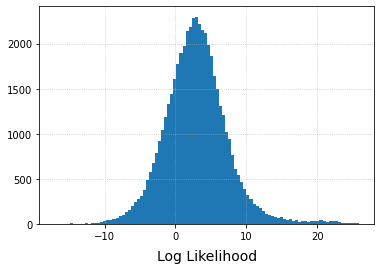

In [21]:
plt.hist(logL, bins=100)
plt.xlabel('Log Likelihood')
plt.show()

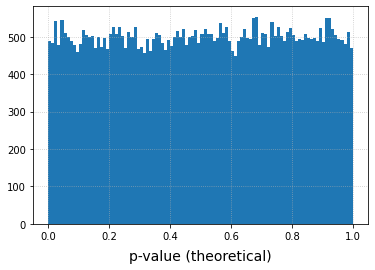

In [22]:
plt.hist(p, bins=100)
plt.xlabel('p-value (theoretical)')
plt.show()